In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import genextreme, genpareto
from statsmodels.tsa.stattools import adfuller
import seaborn as sns 
import sys
import os 
import yaml
import json
from datasets import load_dataset

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
from src.plots import *
from src.region_of_acceptance import *

/Users/pabramov/dev/rt-tools/src/region_of_acceptance.py:1296: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
  "Region of Acceptance $R(\mathbb{X})$\n(Valid GEV Parameter Space)"


### Synthetic data

In [22]:
import time

def generate_A1(n): 
    """A1: Gaussian N(10, 1) [cite: 214]"""
    return np.random.normal(10, 1, n)

def generate_A2(n): 
    """A2: Poisson P(10) [cite: 214]"""
    return np.random.poisson(10, n)

def generate_A3(n): 
    """A3: Gamma(10, 1) [cite: 214]"""
    return np.random.gamma(shape=10.0, scale=1.0, size=n)

def generate_B1(n): 
    """B1: N(10,1) then P(1). Independent but not Identical. [cite: 218]"""
    half = n // 2
    return np.concatenate([np.random.normal(10, 1, half), 
                           np.random.poisson(1, n - half)])

def generate_B2(n): 
    """B2: AR(2). Short-range dependent. [cite: 220]"""
    # X_t = 10 + 0.7*X_{t-1} + 0.25*X_{t-2}
    data = np.zeros(n + 2)
    data[0:2] = 10 / (1 - 0.7 - 0.25) # Steady state mean
    noise = np.random.normal(0, 1, n)
    for i in range(2, n + 2):
        data[i] = 10 + 0.7*data[i-1] + 0.25*data[i-2] + noise[i-2]
    return data[2:]

def generate_B3(n): 
    """B3: ARFIMA(0, 0.25, 0). Long-range dependent. [cite: 222]"""
    # Approximate using FFT for fractional noise (1/f^d behavior)
    noise = np.random.normal(0, 1, n)
    freqs = np.fft.fftfreq(n)
    freqs[0] = 1e-9 # Avoid div by zero
    d = 0.25
    # Spectral density of fractional noise relates to |freq|^-2d
    response = np.abs(2 * np.sin(np.pi * freqs)) ** (-d)
    response[0] = 0
    colored = np.fft.ifft(np.fft.fft(noise) * response).real
    return colored + 0.5 # Constant 0.5

def generate_B4(n): 
    """B4: Trend N(10 + 0.001*i, 1). [cite: 223]"""
    i = np.arange(1, n + 1)
    return np.random.normal(10 + 0.001 * i, 1, n)

# 1. Gumbel (Type I Extreme Value Distribution)
def generate_gumbel(n):
    """
    Generates n samples from the Gumbel distribution.
    Unbounded (defined on the entire real axis).
    Commonly used for: Annual maximum river levels, earthquake magnitudes.
    """
    # loc = location (mu), scale = scale (beta)
    return np.random.gumbel(loc=0.0, scale=1.0, size=n)

# 2. Fréchet (Type II Extreme Value Distribution)
def generate_frechet(n):
    """
    Generates n samples from the Fréchet distribution.
    Bounded below (x > 0). Heavy-tailed.
    Commonly used for: Market crashes, rainfall intensity, flood analysis.
    
    Note: Numpy does not have a direct 'frechet' function. 
    However, if X follows a Weibull distribution, 1/X follows a Fréchet distribution.
    """
    shape = 2.0  # Shape parameter (alpha)
    # 1 / weibull(shape) generates a Fréchet distribution with that shape
    return 1.0 / np.random.weibull(a=shape, size=n)

# 3. Weibull (Type III Extreme Value Distribution)
def generate_weibull(n):
    """
    Generates n samples from the Weibull distribution.
    Bounded below (x > 0). Light-tailed (if shape > 1).
    Commonly used for: Material strength, failure analysis, wind speeds.
    """
    shape = 1.5 # Shape parameter (k)
    return np.random.weibull(a=shape, size=n)

# --- Part 3: Experiment Runner (Replicating Table 1) ---

def run_paper_experiment():
    print("\n=== Replicating Table 1: Synthetic Data Test Rejections ===")
    print(f"Sample Size: 1000 | Significance Level (Local): 0.05 | Expected Global Alpha: ~0.14")
    print("-" * 85)
    print(f"{'Source':<12} | {'Reject Any':<12} | {'Reject KPSS':<12} | {'Reject BDS':<12} | {'Reject R/S':<12}")
    print("-" * 85)

    # Note: Paper used 1,000 evaluations. We use 100 here for execution speed.
    # Set N_EVALS = 1000 to match paper exactly (warning: BDS is slow).
    N_EVALS = 100
    SAMPLE_SIZE = 1000
    
    validator = EVTValidator(local_alpha=0.05)
    
    generators = {
        "A1 (Gaus)": generate_A1,
        "A2 (Pois)": generate_A2,
        "A3 (Gamm)": generate_A3,
        "B1 (Step)": generate_B1,
        "B2 (AR2) ": generate_B2,
        "B3 (Long)": generate_B3,
        "B4 (Trnd)": generate_B4,
        "C1 (Gumb)": generate_gumbel,
        "C2 (Frec)": generate_frechet,
        "C3 (Weib)": generate_weibull 
    }

    for name, gen_func in generators.items():
        counts = {"kpss": 0, "bds": 0, "rs": 0, "any": 0}
        
        # Create matrix of runs for efficient testing if we wanted, 
        # but loop allows tracking individual test failures easier for the table
        for _ in range(N_EVALS):
            data = gen_func(SAMPLE_SIZE)
            res = validator.validate_single_series(data)
            
            if res["kpss"]: counts["kpss"] += 1
            if res["bds"]:  counts["bds"] += 1
            if res["rs"]:   counts["rs"] += 1
            if res["any"]:  counts["any"] += 1

        print(f"{name:<12} | {counts['any']/N_EVALS:<12.1%} | {counts['kpss']/N_EVALS:<12.1%} | {counts['bds']/N_EVALS:<12.1%} | {counts['rs']/N_EVALS:<12.1%}")

    print("-" * 85)
    print("Interpretation:")
    print("A1-A3 (Valid): 'Reject Any' should be close to Global Alpha (~14%).")
    print("B1-B4 (Invalid): 'Reject Any' should be high (near 100%).")

start_time = time.time()
run_paper_experiment()
print(f"\nTotal Execution Time: {time.time() - start_time:.2f} seconds")


=== Replicating Table 1: Synthetic Data Test Rejections ===
Sample Size: 1000 | Significance Level (Local): 0.05 | Expected Global Alpha: ~0.14
-------------------------------------------------------------------------------------
Source       | Reject Any   | Reject KPSS  | Reject BDS   | Reject R/S  
-------------------------------------------------------------------------------------
A1 (Gaus)    | 10.0%        | 4.0%         | 4.0%         | 3.0%        
A2 (Pois)    | 9.0%         | 1.0%         | 5.0%         | 3.0%        
A3 (Gamm)    | 10.0%        | 3.0%         | 2.0%         | 5.0%        
B1 (Step)    | 100.0%       | 100.0%       | 100.0%       | 100.0%      
B2 (AR2)     | 100.0%       | 34.0%        | 100.0%       | 100.0%      
B3 (Long)    | 100.0%       | 37.0%        | 99.0%        | 98.0%       
B4 (Trnd)    | 100.0%       | 100.0%       | 10.0%        | 10.0%       
C1 (Gumb)    | 13.0%        | 9.0%         | 4.0%         | 1.0%        
C2 (Frec)    | 9.0%       

INFO:root:Checking 512000 points...
INFO:root:Region construction complete. Found 130516 valid points.


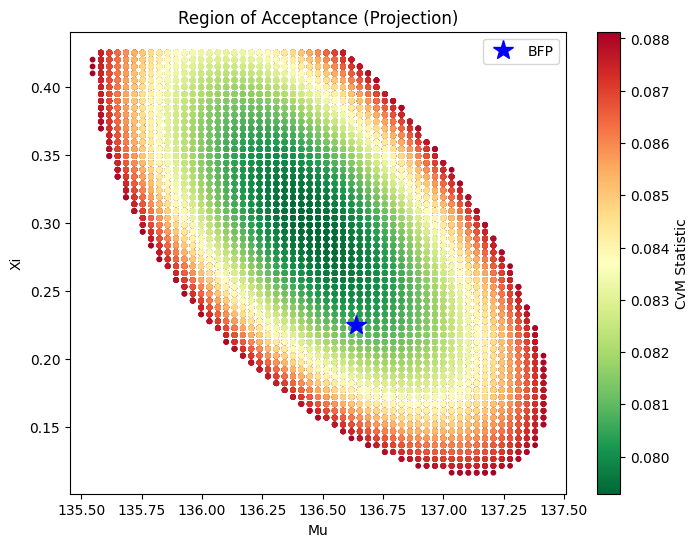

In [2]:
# Simulate Data (e.g., similar to D1/D2 in paper)
np.random.seed(42)
# Generate synthetic Frechet data
data = stats.genextreme.rvs(c=-0.1, loc=100, scale=10, size=1000)

roa = RegionOfAcceptance(data, block_size=30)
roa.explore(resolution=80, range_pct=0.01)
roa.plot_roa()

INFO:matplotlib.mathtext:Substituting symbol X from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol X from STIXNonUnicode


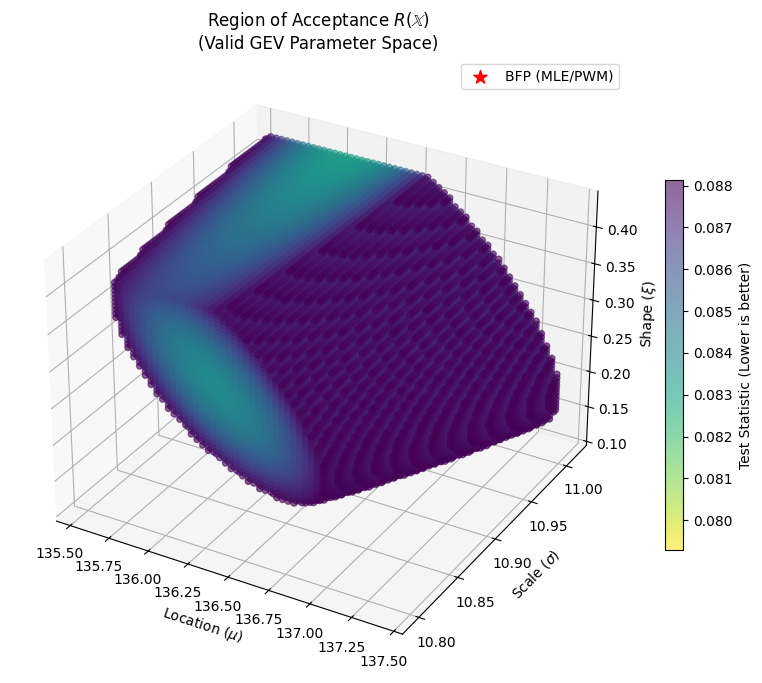

In [3]:
roa.plot_3d()

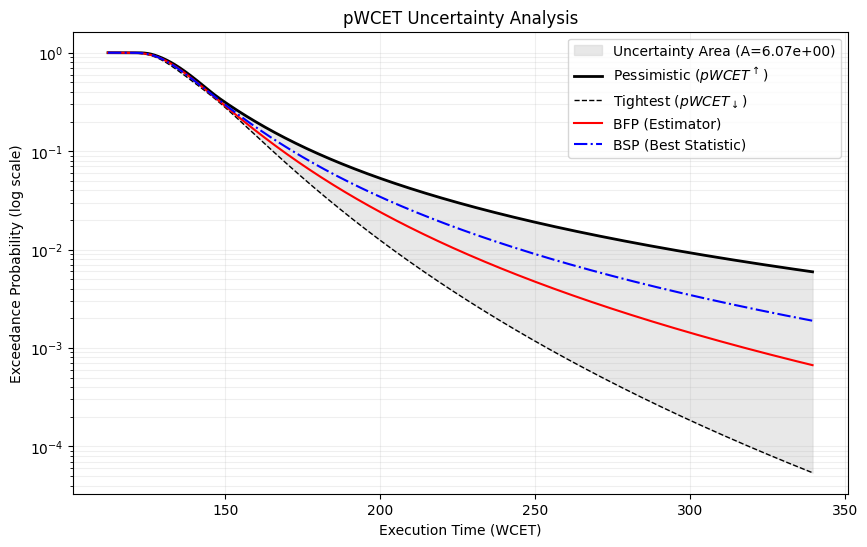

In [4]:
roa.plot_uncertainty_area()

INFO:root:Checking 512000 points...


--- Running Gumbel Analysis ---


INFO:root:Region construction complete. Found 95065 valid points.


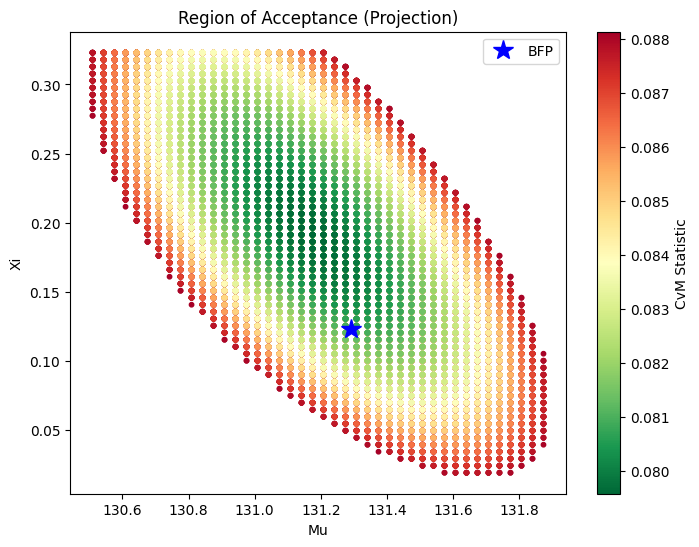

In [5]:
# --- Gumbel Example (Light Tail) ---
# Represents systems with exponentially decaying probabilities (e.g., Gaussian processes)

np.random.seed(42)
# Generate synthetic Gumbel data (xi = 0)
# Note: c = -xi, so c = 0.0
gumbel_data = stats.genextreme.rvs(c=0.0, loc=100, scale=10, size=1000)

print("--- Running Gumbel Analysis ---")
roa_gumbel = RegionOfAcceptance(gumbel_data, block_size=30)

# Explore region
# We use a slightly larger range_pct because Gumbel regions can be narrow
roa_gumbel.explore(resolution=80, range_pct=0.01)
roa_gumbel.plot_roa()


INFO:matplotlib.mathtext:Substituting symbol X from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol X from STIXNonUnicode


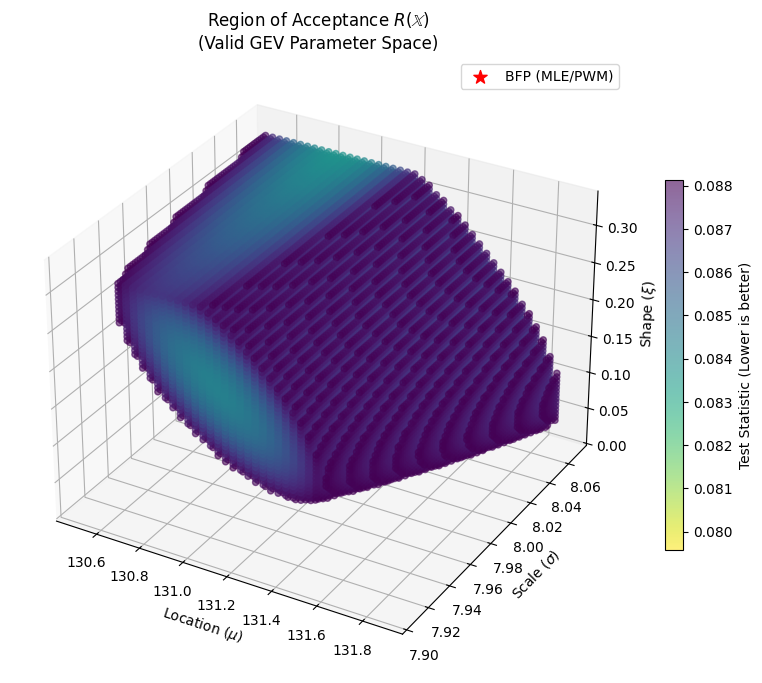

In [6]:
roa_gumbel.plot_3d()

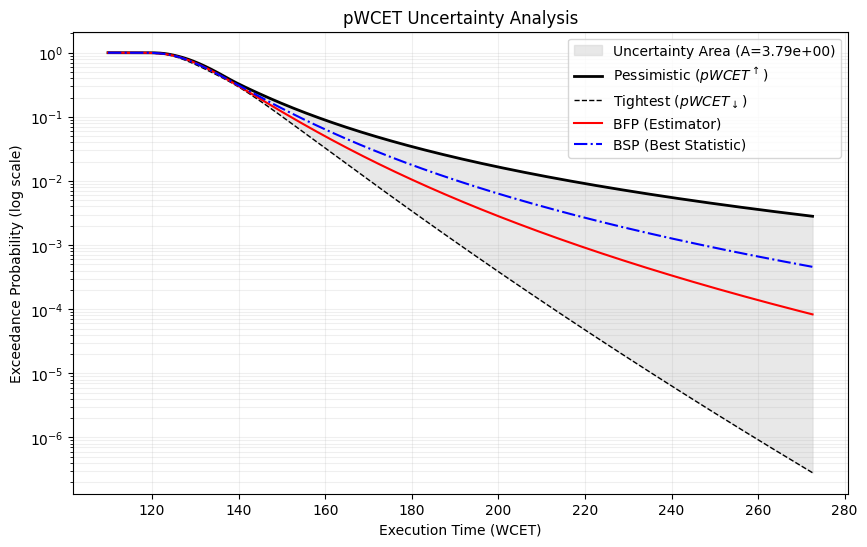

In [7]:
roa_gumbel.plot_uncertainty_area()

INFO:root:Checking 512000 points...


--- Running Weibull Analysis ---


INFO:root:Region construction complete. Found 39386 valid points.


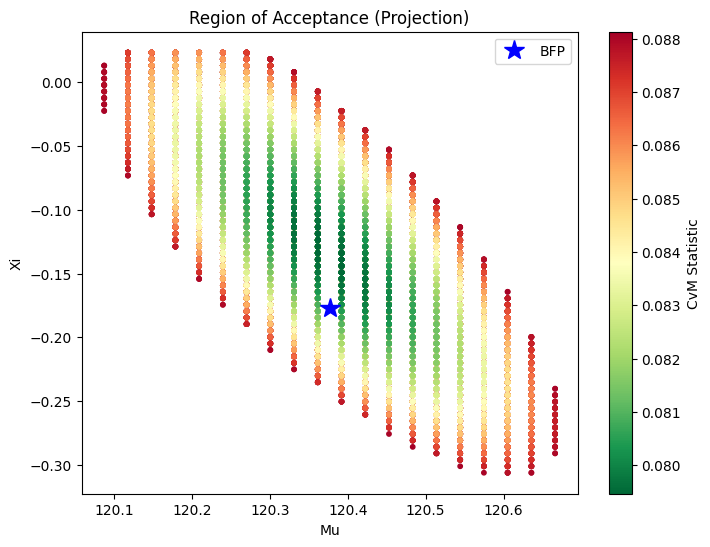

In [8]:
# --- Weibull Example (Bounded Tail) ---
# Represents systems with a finite maximum execution time.

np.random.seed(42)
# Generate synthetic Weibull data (xi = -0.3)
# Note: c = -xi, so c = 0.3
weibull_data = stats.genextreme.rvs(c=0.3, loc=100, scale=10, size=1000)

print("--- Running Weibull Analysis ---")
roa_weibull = RegionOfAcceptance(weibull_data, block_size=30)

# Explore region
roa_weibull.explore(resolution=80, range_pct=0.01)

# Plot 3D (Mu, Sigma, Xi)
roa_weibull.plot_roa()

INFO:matplotlib.mathtext:Substituting symbol X from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol X from STIXNonUnicode


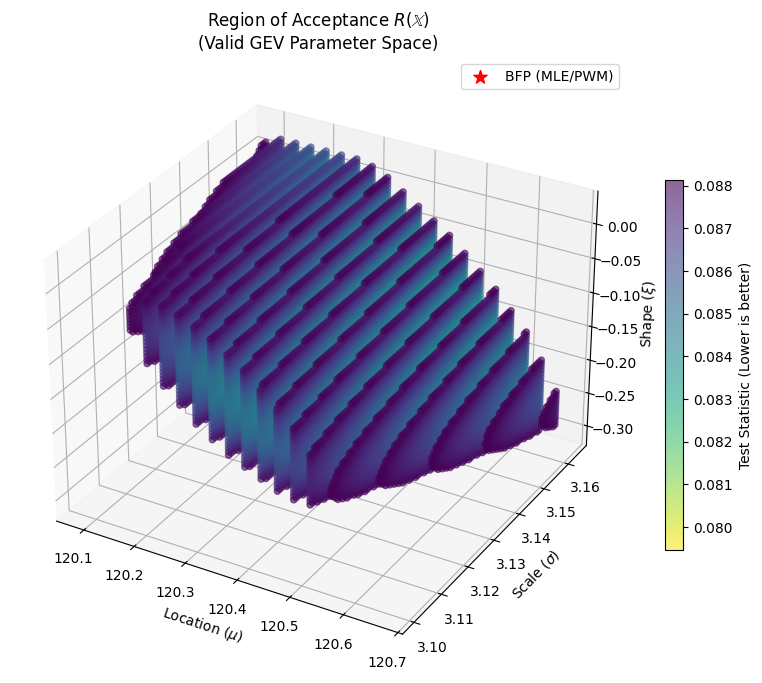

In [9]:
roa_weibull.plot_3d()

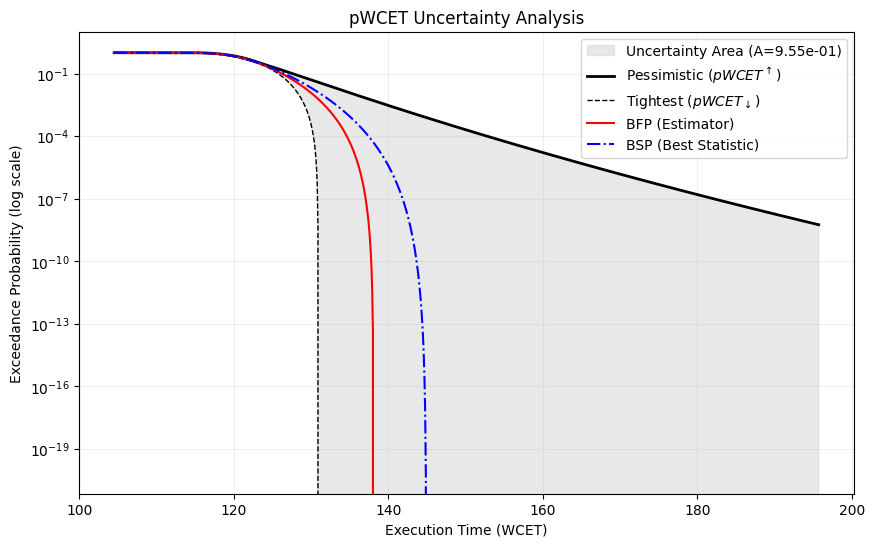

In [10]:
roa_weibull.plot_uncertainty_area()

INFO:root:Checking 64000 points...
INFO:root:Region construction complete. Found 16021 valid points.
INFO:matplotlib.mathtext:Substituting symbol X from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol X from STIXNonUnicode


Generating synthetic Fréchet data...
Initializing Region of Acceptance...
Exploring parameter space...
Plotting 3D Region of Acceptance...


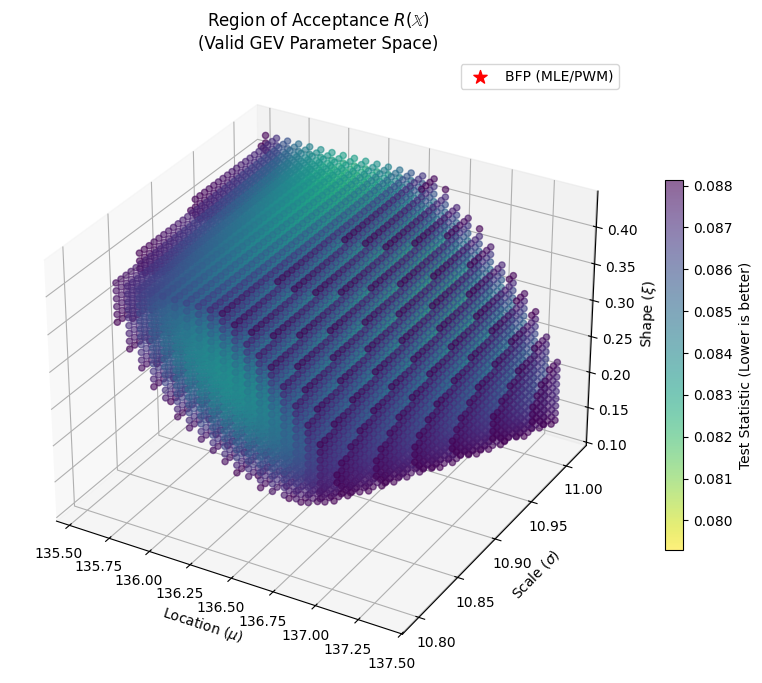

Plotting pWCET Uncertainty Area...


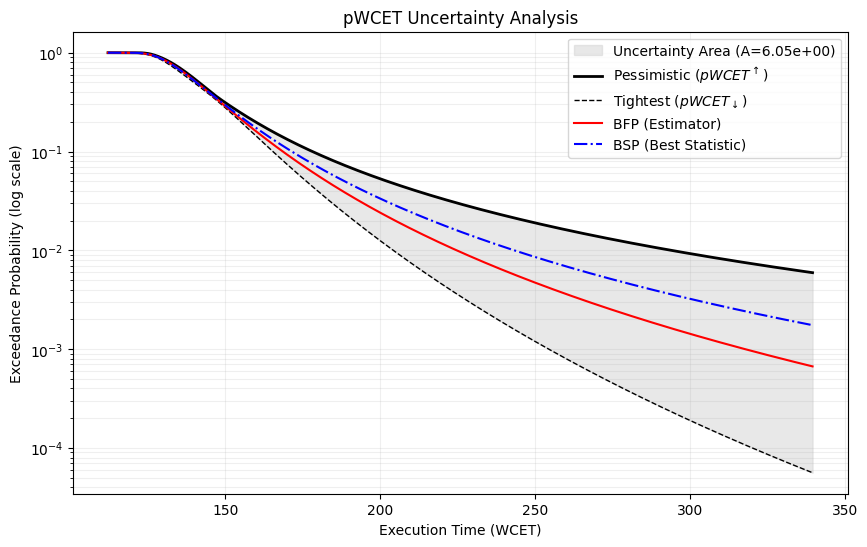

In [11]:
np.random.seed(42)

# 1. Generate synthetic Fréchet data (Heavy Tail)
# Note: Scipy uses c = -xi. For Fréchet, we need xi > 0 (e.g., 0.1), so c = -0.1.
# We increase size to 5000 to ensure we have enough blocks (5000/30 = 166 blocks).
print("Generating synthetic Fréchet data...")
data = stats.genextreme.rvs(c=-0.1, loc=100, scale=10, size=1000)

# 2. Initialize Region of Acceptance
# We use a block size of 30, yielding ~166 maxima, which is healthy for EVT.
print("Initializing Region of Acceptance...")
roa = RegionOfAcceptance(data, block_size=30)

# 3. Explore the Region
# resolution=40: Checks 40^3 = 64,000 points (fast with vectorization)
# range_pct=0.15: Searches +/- 15% around the MLE estimate
print("Exploring parameter space...")
roa.explore(resolution=40, range_pct=0.01)

# 4. Plot 3D Region (The "Epsilon" Cloud)
# Shows the valid Mu, Sigma, Xi combinations
print("Plotting 3D Region of Acceptance...")
roa.plot_3d()

# 5. Plot Uncertainty Area (The pWCET Curves)
# Shows the Pessimistic vs Tightest bounds [cite: 448]
print("Plotting pWCET Uncertainty Area...")
roa.plot_uncertainty_area()

### Real-world data

In [13]:
! ls ../data/jitter

2025-12-15 2025-12-17 2025-12-18 2025-12-19 2025-12-20


In [14]:
import pandas as pd
from pathlib import Path

def csv_generator(root_dir):
    # Convert string path to Path object
    root_path = Path(root_dir)
    
    # Iterate using glob to match the specific structure
    # pattern: root/yyyy-mm-dd/hh-mm-ss/output.csv
    # The pattern */* matches the date/time folders
    for file_path in root_path.glob('*/*/output.csv'):
        try:
            date_folder = file_path.parent.parent.name 
            time_folder = file_path.parent.name
            
            df = pd.read_csv(file_path)
            
            df['source_date'] = date_folder
            df['source_time'] = time_folder
            
            yield df, file_path
            
        except Exception as e:
            print(f"Error loading {file_path}: {e}")

In [20]:
data_loader = csv_generator('../data/jitter')

counts = {"kpss": 0, "bds": 0, "rs": 0, "any": 0}
validator = EVTValidator(local_alpha=0.05)
name = "real"
cnt = 0

print("-" * 85)
print(f"{'Source':<12} | {'Reject Any':<12} | {'Reject KPSS':<12} | {'Reject BDS':<12} | {'Reject R/S':<12}")
print("-" * 85)

for df, path in data_loader:
    res = validator.validate_single_series(df.SessionJitter)
    if res["kpss"]: counts["kpss"] += 1
    if res["bds"]:  counts["bds"] += 1
    if res["rs"]:   counts["rs"] += 1
    if res["any"]:  counts["any"] += 1
    cnt += 1

print(f"{name:<12} | {counts['any']/cnt:<12.1%} | {counts['kpss']/cnt:<12.1%} | {counts['bds']/cnt:<12.1%} | {counts['rs']/cnt:<12.1%}")

-------------------------------------------------------------------------------------
Source       | Reject Any   | Reject KPSS  | Reject BDS   | Reject R/S  
-------------------------------------------------------------------------------------
real         | 100.0%       | 93.2%        | 100.0%       | 100.0%      


In [21]:
counts

{'kpss': 96, 'bds': 103, 'rs': 103, 'any': 103}

Plot created from 100 sessions.


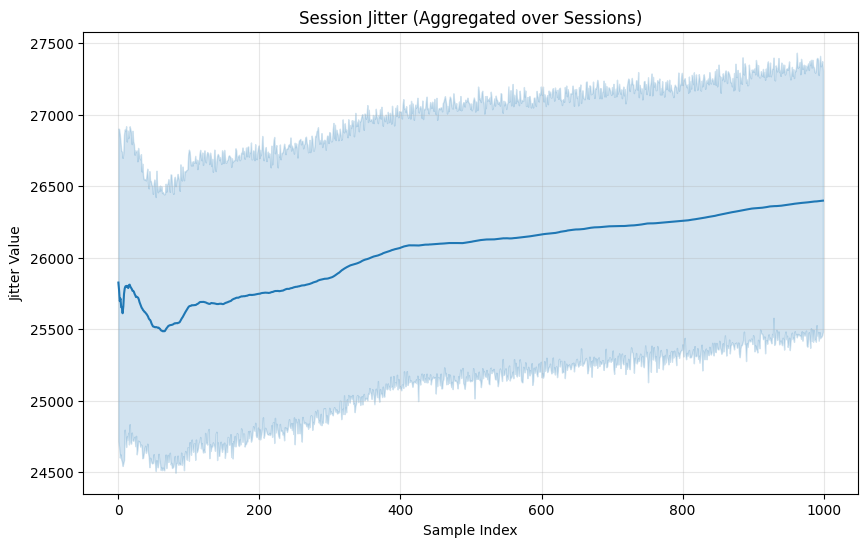

In [24]:
valid_dfs = []
data_loader = csv_generator('../data/jitter')

for df, path in data_loader:
    if len(df) == 1000:
        df['sample_index'] = range(len(df))
        valid_dfs.append(df)

if valid_dfs:
    combined_df = pd.concat(valid_dfs, ignore_index=True)

    plt.figure(figsize=(10, 6))
    
    # 'errorbar="sd"' shows the Standard Deviation as the uncertainty area. 
    # Use errorbar=("ci", 95) for a 95% Confidence Interval.
    sns.lineplot(
        data=combined_df, 
        x='sample_index', 
        y='SessionJitter', 
        errorbar=("ci", 95)  
    )
    
    plt.title('Session Jitter (Aggregated over Sessions)')
    plt.xlabel('Sample Index')
    plt.ylabel('Jitter Value')
    plt.grid(True, alpha=0.3)
    plt.savefig('session_jitter_uncertainty.png')
    
    print(f"Plot created from {len(valid_dfs)} sessions.")
else:
    print("No datasets with exactly 1000 samples were found.")

Plot saved. Aggregated 103 experiments.


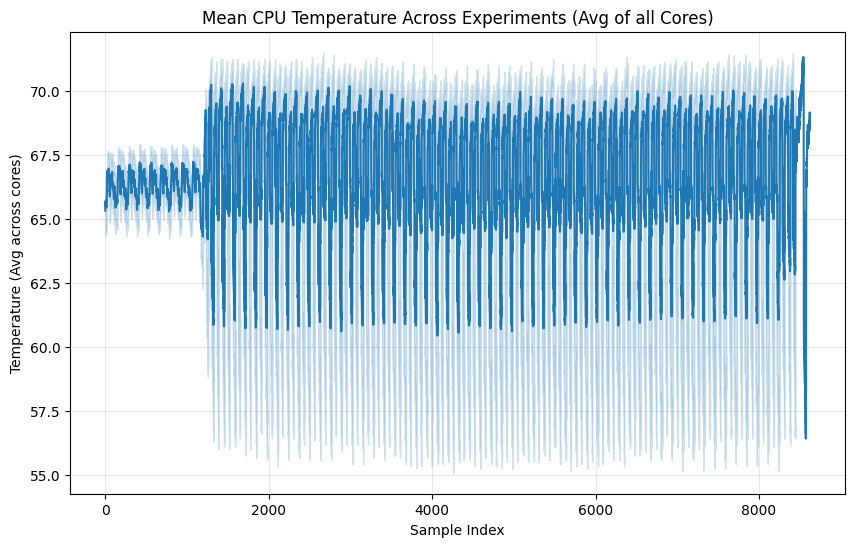

In [30]:
def cpu_data_generator(root_dir):
    """
    Generator that yields dataframes from matching cpu_monitor.csv files.
    """
    root_path = Path(root_dir)
    for file_path in root_path.glob('*/*/cpu_monitor.csv'):
        try:
            df = pd.read_csv(file_path)
            yield df
        except Exception as e:
            print(f"Error reading {file_path}: {e}")

# 1. Load and Process Data
valid_dfs = []
data_loader = cpu_data_generator('../data/jitter') # Ensure this matches your root folder name

for df in data_loader:
    # Identify columns related to Cores
    # We assume columns containing "Core" hold the temperature data
    core_cols = [c for c in df.columns if 'Core' in c]
    
    # Calculate the mean across all core columns for this specific dataset
    # axis=1 calculates the mean across columns (horizontally)
    df['dataset_avg_temp'] = df[core_cols].mean(axis=1)
    
    # Keep only the index and the calculated average
    df_processed = pd.DataFrame({
        'sample_index': range(len(df)),
        'avg_temp': df['dataset_avg_temp']
    })
    
    valid_dfs.append(df_processed)

# 2. Combine and Plot
if valid_dfs:
    # Concatenate all processed datasets
    combined_df = pd.concat(valid_dfs, ignore_index=True)

    plt.figure(figsize=(10, 6))
    
    # Plotting
    # errorbar=('ci', 95) calculates the 95% Confidence Interval
    sns.lineplot(
        data=combined_df, 
        x='sample_index', 
        y='avg_temp', 
        errorbar=('ci', 95)
    )
    
    plt.title('Mean CPU Temperature Across Experiments (Avg of all Cores)')
    plt.xlabel('Sample Index')
    plt.ylabel('Temperature (Avg across cores)')
    plt.grid(True, alpha=0.3)
    
    plt.savefig('avg_cpu_temp_experiment.png')
    print(f"Plot saved. Aggregated {len(valid_dfs)} experiments.")
else:
    print("No valid datasets found.")